In [2]:
# import kagglehub
#
# # Download latest version
# path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")
#
# print("Path to dataset files:", path)

In [3]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')
import nltk

In [4]:
df = pd.read_csv(r"C:\Users\nguye\OneDrive\Documents\Data Analysis\sentiment_Analysis_Project\Reviews.csv")

In [5]:
df = df.head(1000)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Id                      1000 non-null   int64 
 1   ProductId               1000 non-null   object
 2   UserId                  1000 non-null   object
 3   ProfileName             1000 non-null   object
 4   HelpfulnessNumerator    1000 non-null   int64 
 5   HelpfulnessDenominator  1000 non-null   int64 
 6   Score                   1000 non-null   int64 
 7   Time                    1000 non-null   int64 
 8   Summary                 1000 non-null   object
 9   Text                    1000 non-null   object
dtypes: int64(5), object(5)
memory usage: 78.2+ KB


In [7]:
df.isnull().sum()

Id                        0
ProductId                 0
UserId                    0
ProfileName               0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Time                      0
Summary                   0
Text                      0
dtype: int64

In [8]:
df.dropna(inplace=True)

In [9]:
ex = df['Text'][50]

In [10]:

from nltk.tokenize import word_tokenize
token=nltk.word_tokenize(ex)

In [11]:
tagged=nltk.pos_tag(token)

In [12]:
entitied=nltk.chunk.ne_chunk(tagged)
entitied.pprint()

(S
  This/DT
  oatmeal/NN
  is/VBZ
  not/RB
  good/JJ
  ./.
  Its/PRP$
  mushy/NN
  ,/,
  soft/JJ
  ,/,
  I/PRP
  do/VBP
  n't/RB
  like/VB
  it/PRP
  ./.
  (ORGANIZATION Quaker/NNP Oats/NNPS)
  is/VBZ
  the/DT
  way/NN
  to/TO
  go/VB
  ./.)


In [13]:
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm
nltk.download('vader_lexicon')
sia=SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\nguye\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [14]:
sia.polarity_scores(ex)

{'neg': 0.22, 'neu': 0.78, 'pos': 0.0, 'compound': -0.5448}

In [15]:
from tqdm import tqdm


In [16]:
res={}
for i,row in tqdm(df.iterrows(),total=len(df)):
    text=row['Text']
    myid=row['Id']
    res[myid]=sia.polarity_scores(text)

100%|██████████| 1000/1000 [00:00<00:00, 1546.36it/s]


In [17]:
vaders = pd.DataFrame(res).T
vaders=vaders.reset_index().rename(columns={'index':'Id'})
vaders = vaders.merge(df, how='left')

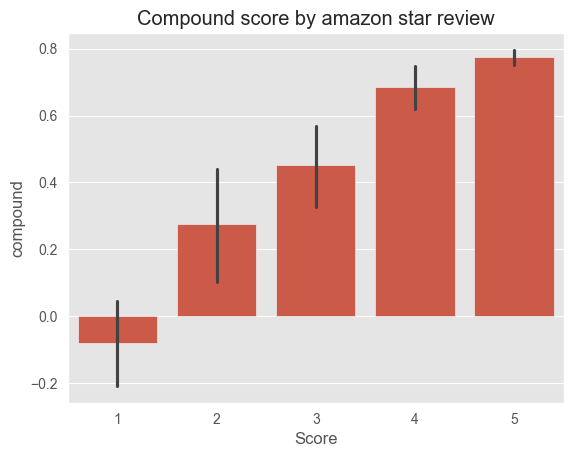

In [18]:
ax = sns.barplot(data=vaders,x="Score",y="compound")
ax.set_title('Compound score by amazon star review')
plt.show()

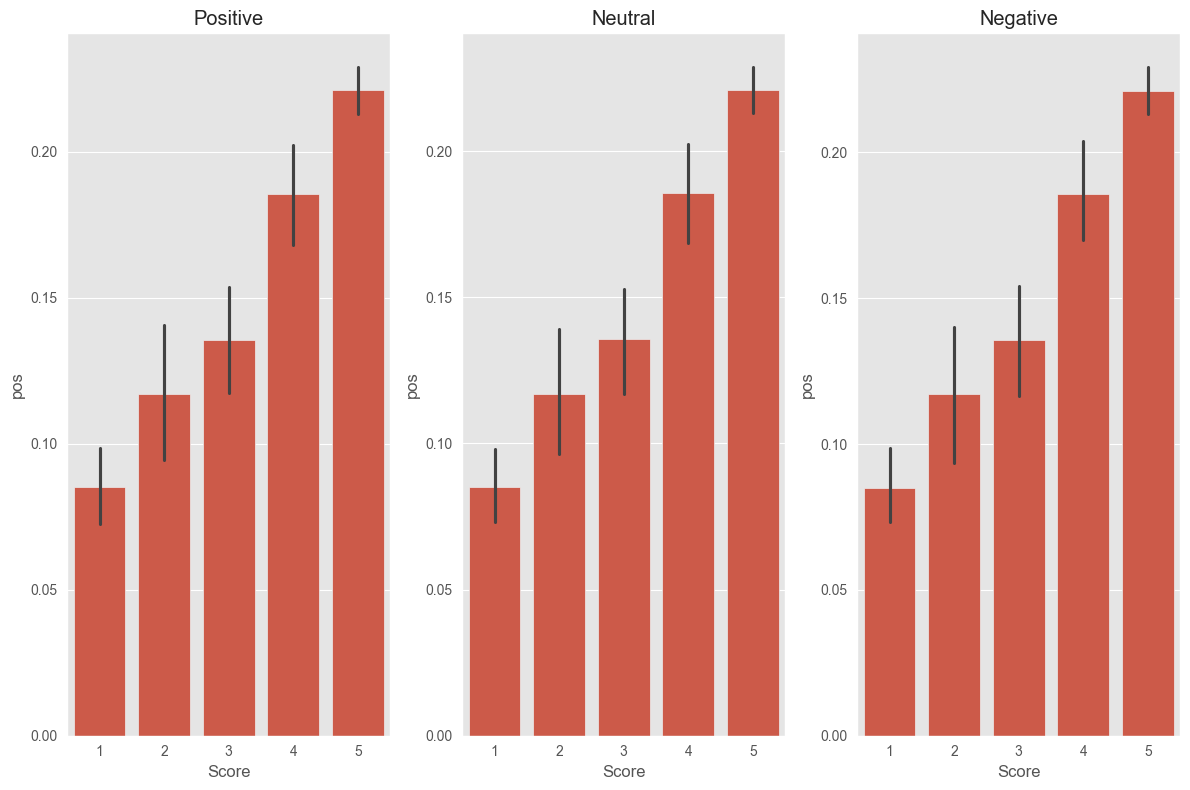

In [19]:
fig , axs = plt.subplots(1,3,figsize= (12,8))
sns.barplot(data=vaders,x='Score',y='pos',ax=axs[0])
sns.barplot(data=vaders,x='Score',y='pos',ax=axs[1])
sns.barplot(data=vaders,x='Score',y='pos',ax=axs[2])
axs[0].set_title('Positive')
axs[1].set_title('Neutral')
axs[2].set_title('Negative')
plt.tight_layout()

plt.show()

In [20]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from scipy.special import softmax

In [21]:
! pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu


In [22]:
import torch
print(torch.__version__)
! pip install hf_xet

2.7.1+cpu


In [23]:
MODEL = f'cardiffnlp/twitter-roberta-base-sentiment'
tokenizer=AutoTokenizer.from_pretrained(MODEL)
model=AutoModelForSequenceClassification.from_pretrained(MODEL)

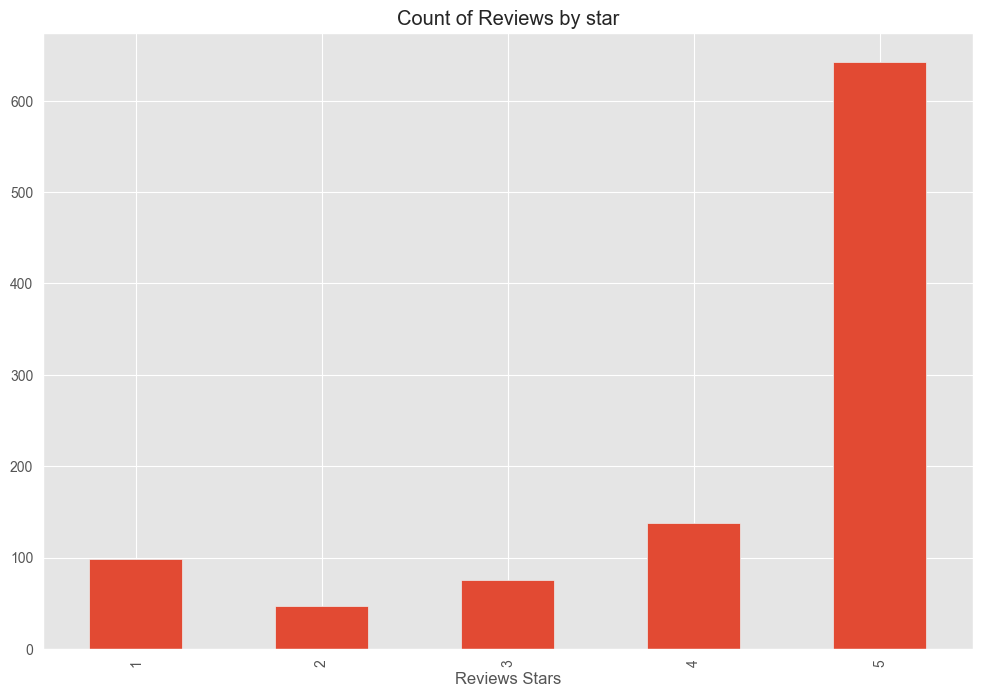

In [24]:
ax = df['Score'].value_counts().sort_index().plot(kind="bar",
                                             title="Count of Reviews by star",
                                             figsize=(12,8))
ax.set_xlabel("Reviews Stars")
plt.show()

In [25]:
encoded_text = tokenizer(ex, return_tensors='pt')
outputs = model(**encoded_text)
scores = outputs[0][0].detach().numpy()
scores = softmax(scores)
scores_dict={
    'roberta_neg' : scores[0],
    'roberta_neu' : scores[1],
    'roberta_pos' : scores[2],
}
print(scores_dict)

{'roberta_neg': 0.97635514, 'roberta_neu': 0.020687466, 'roberta_pos': 0.0029573692}


In [26]:
def polarity_scores_roberta(ex):
    encoded_text = tokenizer(ex, return_tensors='pt')
    outputs = model(**encoded_text)
    scores = outputs[0][0].detach().numpy()
    scores = softmax(scores)
    scores_dict={
        'roberta_neg' : scores[0],
        'roberta_neu' : scores[1],
        'roberta_pos' : scores[2],
    }
    return (scores_dict)

In [27]:

res={}
for i,row in tqdm(df.iterrows(),total=len(df)):
    try:
        text=row['Text']
        myid=row['Id']
        vaders_res=sia.polarity_scores(text)
        vaders_res_rename={}
        for key,value in vaders_res.items():
            vaders_res_rename[f"vader_{key}"]=value
        roberta_res = polarity_scores_roberta(text)
        both = {**vaders_res_rename, **roberta_res}
        res[myid]=both
    except RuntimeError:
        print(f'Broke for id: {myid}')

  8%|▊         | 83/1000 [00:09<01:17, 11.87it/s]

Broke for id: 83


 19%|█▉        | 189/1000 [00:21<01:12, 11.17it/s]

Broke for id: 187


 53%|█████▎    | 530/1000 [01:04<00:51,  9.13it/s]

...

 74%|███████▍  | 745/1000 [01:29<00:40,  6.34it/s]

Broke for id: 746


 86%|████████▋ | 865/1000 [01:49<00:15,  8.81it/s]

Broke for id: 863


100%|██████████| 1000/1000 [02:11<00:00,  7.59it/s]


In [28]:
res_df = pd.DataFrame(res).T
res_df = res_df.reset_index().rename(columns={'index':'Id'})
res_df = res_df.merge(df, how='left')

In [29]:
res_df.columns

Index(['Id', 'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound',
       'roberta_neg', 'roberta_neu', 'roberta_pos', 'ProductId', 'UserId',
       'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator',
       'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

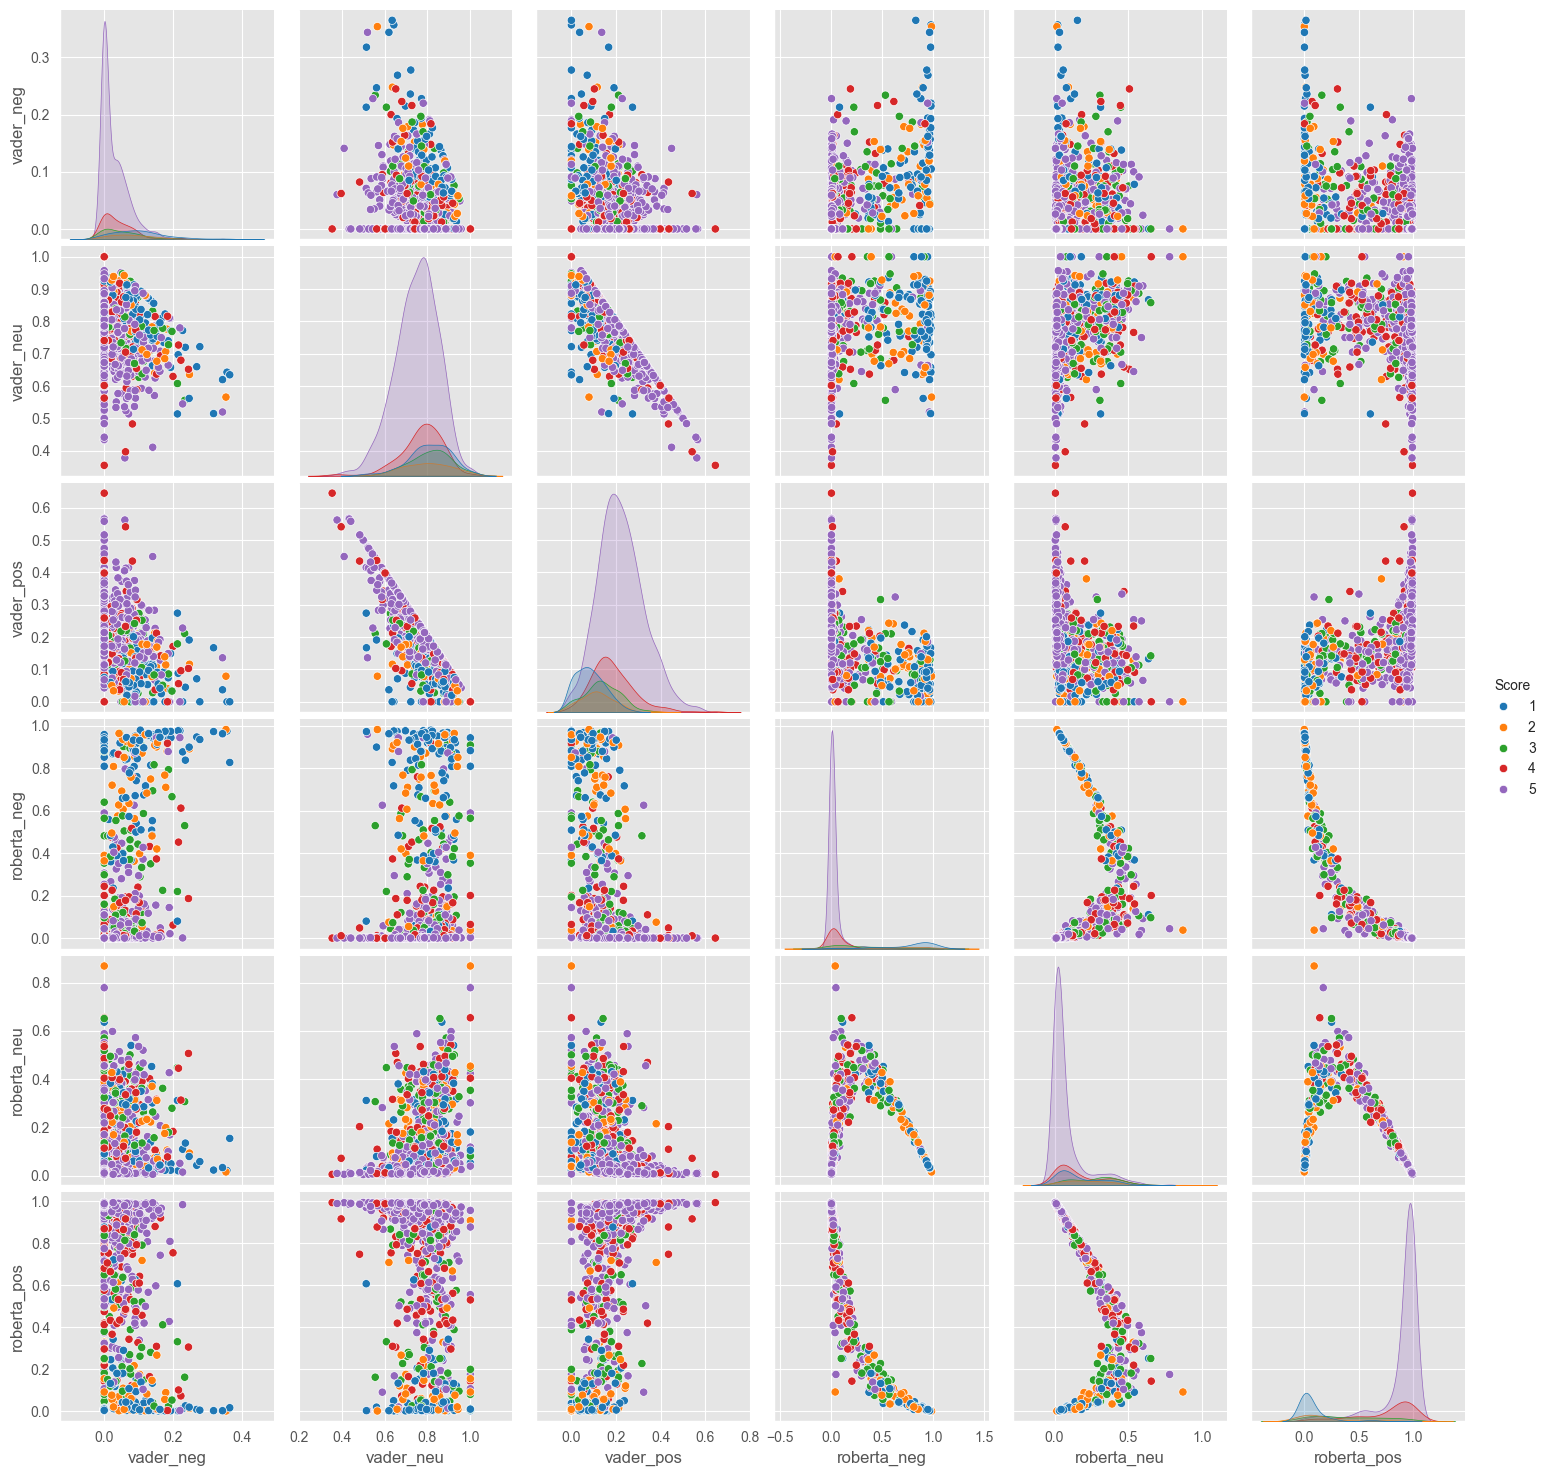

In [30]:
sns.pairplot(data=res_df,
             vars=['vader_neg','vader_neu','vader_pos',
                  'roberta_neg','roberta_neu','roberta_pos']
             ,hue='Score',
             palette='tab10')
plt.show()

In [31]:
res_df.query('Score==1') \
    .sort_values('roberta_pos', ascending=False)['Text'].values[0]

"I just wanted to post here that I found small bits of plastic in this food as I was feeding my 9 month old.  Plastic!!! in food!!!! baby food!!!  So please be careful if you buy this or are considering it.<br /><br />My daughter LOVES this food-- it's actually her favorite.  This is the first time we have noticed plastic in it in over 2 months."

In [32]:
res_df.query('Score==1') \
    .sort_values('vader_pos', ascending=False)['Text'].values[0]

'So we cancelled the order.  It was cancelled without any problem.  That is a positive note...'